# Market Basket Analysis using Apriori Algorithm

This project performs Market Basket Analysis using Association Rule Mining.  
The Apriori algorithm is used to discover relationships between items frequently purchased together in transactions.

Dataset Source: Kaggle
Goal: Identify frequent itemsets and generate association rules that can help retailers understand customer purchasing patterns.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [20]:
df = pd.read_csv("Groceries_dataset.csv")

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [21]:
df.shape

(38765, 3)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [23]:
df.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [24]:
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [25]:
df['TransactionID'] = df['Member_number'].astype(str) + "_" + df['Date'].astype(str)

df.head()

,Member_number,Date,itemDescription,TransactionID
0,1808,21-07-2015,tropical fruit,1808_21-07-2015
1,2552,05-01-2015,whole milk,2552_05-01-2015
2,2300,19-09-2015,pip fruit,2300_19-09-2015
3,1187,12-12-2015,other vegetables,1187_12-12-2015
4,3037,01-02-2015,whole milk,3037_01-02-2015


In [26]:
basket = (df
          .groupby(['TransactionID','itemDescription'])['itemDescription']
          .count()
          .unstack()
          .fillna(0)
          )

basket.head()

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
TransactionID,,,,,,,,,,,,,,,,,,,,,
1000_15-03-2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1000_24-06-2014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1000_24-07-2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000_25-11-2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000_27-05-2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

C:\Users\anees\AppData\Local\Temp\ipykernel_33316\2737237846.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
TransactionID,,,,,,,,,,,,,,,,,,,,,
1000_15-03-2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1000_24-06-2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1000_24-07-2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_25-11-2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_27-05-2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.021386,(UHT-milk)
1,0.033950,(beef)
2,0.021787,(berries)
3,0.045312,(bottled beer)
4,0.060683,(bottled water)


In [29]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [30]:
rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


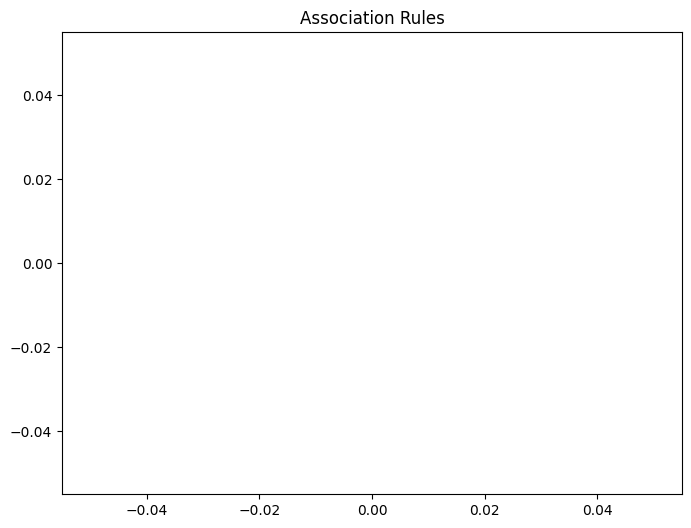

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    data=rules
)

plt.title("Association Rules")
plt.show()

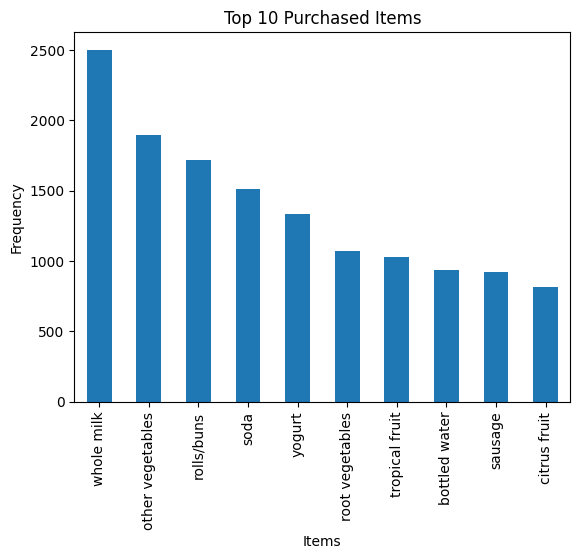

In [32]:
top_items = df['itemDescription'].value_counts().head(10)

top_items.plot(kind='bar')

plt.title("Top 10 Purchased Items")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.show()

## K-Means Clustering


In [33]:
X = basket.values

k = 3
centroids = X[np.random.choice(X.shape[0], k, replace=False)]

for i in range(10):
    
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    
    labels = np.argmin(distances, axis=0)
    
    new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
    
    if np.all(centroids == new_centroids):
        break
        
    centroids = new_centroids

print("Cluster labels:", labels[:20])

Cluster labels: [0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0]


## Hierarchical Clustering

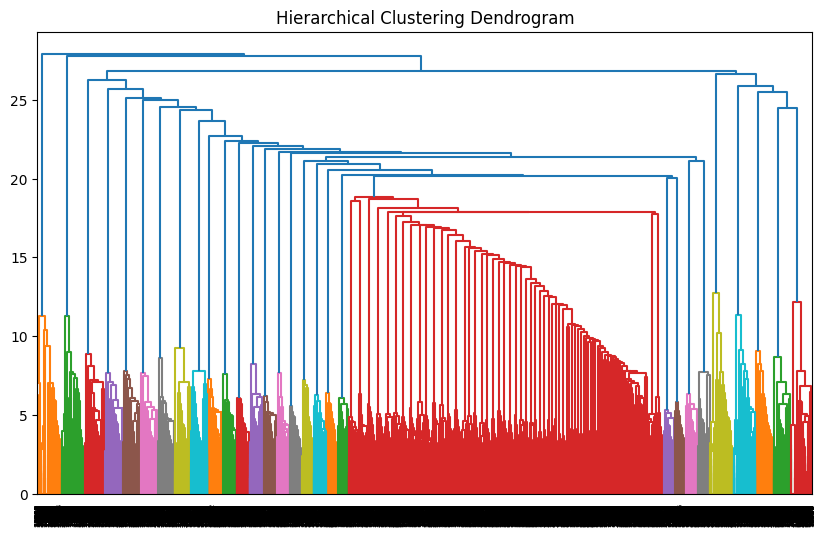

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(basket, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## PCA (Dimensionality Reduction)

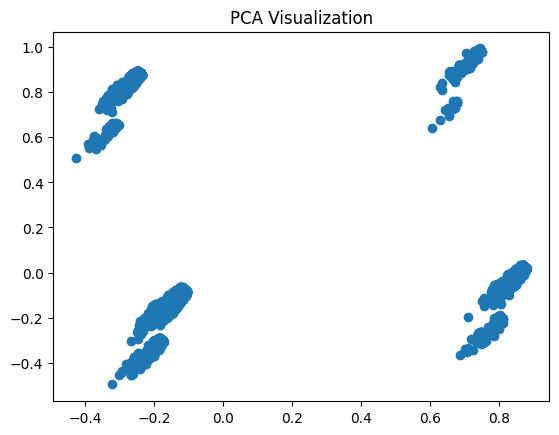

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(basket)

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])

pca_df.head()

plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Visualization")
plt.show()

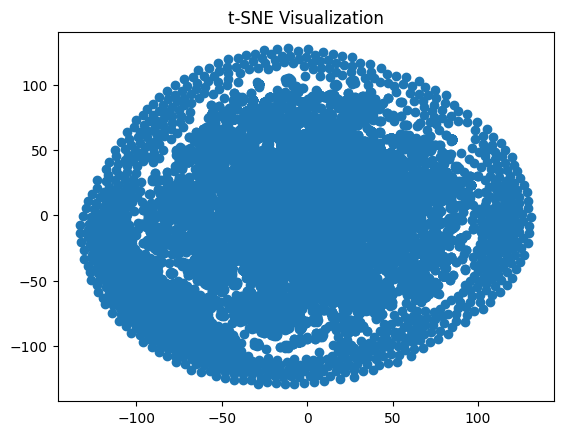

In [36]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

tsne_result = tsne.fit_transform(basket)

tsne_df = pd.DataFrame(tsne_result, columns=['Dim1','Dim2'])

plt.scatter(tsne_df['Dim1'], tsne_df['Dim2'])
plt.title("t-SNE Visualization")
plt.show()

## Association Rule Mining (Apriori)

In [37]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.head()

rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


### Conclusion

This project applied Market Basket Analysis using the Apriori algorithm on the groceries dataset.  
Frequent itemsets and association rules revealed relationships between products that customers buy together.  
These insights can help retailers improve cross-selling strategies and product placement.